# Problema de regresie

## Definirea problemei

În această parte a proiectului este abordată o problemă de regresie. Scopul este construirea unor modele de Machine Learning capabile să prezică valoarea numerică a variabilei 'quality', care reprezintă scorul de calitate al vinului.

Setul de date conține informații despre proprietăți fizico-chimice ale vinului, precum aciditatea, cantitatea de zahăr rezidual, nivelul de cloruri, dioxidul de sulf, densitatea, pH-ul, nivelul de sulfați și procentul de alcool.

Relevanța practică a problemei constă în posibilitatea de a estima calitatea unui vin pe baza unor măsurători obiective, obținute în laborator. Un astfel de model poate fi util pentru producători, laboratoare sau specialiști în controlul calității, deoarece poate oferi o estimare rapidă a calității vinului înainte de evaluarea finală.

Am ales această problemă deoarece setul de date este potrivit pentru regresie, are un număr adecvat de observații pentru proiect și conține doar caracteristici numerice, ceea ce permite aplicarea și compararea clară a mai multor modele de regresie.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
import numpy as np

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

from sklearn.gaussian_process import GaussianProcessRegressor

from xgboost import XGBRegressor

from catboost import CatBoostRegressor

from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import learning_curve

import shap

In [3]:
df = pd.read_csv("../data/regression_dataset.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [4]:
print("Dimensiune dataset:", df.shape)
print("Coloane dataset:")
print(df.columns)

Dimensiune dataset: (1699, 12)
Coloane dataset:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


## Descrierea setului de date

Variabila de ieșire este 'quality', scorul de calitate al vinului. Scopul modelului nu este să încadreze vinul într-o clasă fixă, ci să estimeze cât mai corect valoarea scorului de calitate.

Caracteristicile de intrare sunt:

    - 'fixed acidity'
    - 'volatile acidity'
    - 'citric acid'
    - 'residual sugar'
    - 'chlorides'
    - 'free sulfur dioxide'
    - 'total sulfur dioxide'
    - 'density'
    - 'pH'
    - 'sulphates'
    - 'alcohol'

In [5]:
df["quality"].value_counts().sort_index()

quality
3.000000    10
3.850377     1
3.897010     1
3.961616     1
3.989201     1
            ..
7.167815     1
7.325771     1
7.761854     1
7.832748     1
8.000000    18
Name: count, Length: 106, dtype: int64

In [6]:
print("Valoarea minima pentru quality:", df["quality"].min())
print("Valoarea maxima pentru quality:", df["quality"].max())

Valoarea minima pentru quality: 3.0
Valoarea maxima pentru quality: 8.0


### Interpretarea variabilei țintă

În acest set de date, variabila 'quality' are valori între 3 și 8. Aceste valori reprezintă scoruri de calitate atribuite vinurilor. Deși valorile sunt numere întregi, problema este tratată ca regresie deoarece se urmărește estimarea numerică a scorului de calitate, nu clasificarea vinului într-o categorie fixă.

Scorul 'quality' nu are o unitate de măsură fizică, fiind un scor de evaluare a calității.

## Analiza exploratorie a datelor

În această etapă analizăm structura setului de date, tipurile de date și valorile lipsă. Această analiză este necesară pentru a înțelege calitatea datelor și pentru a pregăti corect setul de date pentru modelele de regresie.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   float64
dtypes: float64(12)
memory usage: 159.4 KB


In [8]:
print("Numarul de valori lipsa pentru fiecare coloana:")
print(df.isnull().sum())

Numarul de valori lipsa pentru fiecare coloana:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Interpretarea structurii datelor și a valorilor lipsă

Setul de date conține 1699 de observații și 12 coloane. Toate coloanele sunt de tip float64, ceea ce înseamnă că datele pot fi folosite direct de modelele de regresie, fără să fie necesară codificarea unor variabile.

În urma verificării valorilor lipsă, se observă că fiecare coloană are 0 valori lipsă. Prin urmare, nu este necesară eliminarea unor rânduri sau completarea valorilor absente.

Acest lucru simplifică etapa de preprocesare, deoarece setul de date este complet și conține doar variabile numerice.

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Interpretarea statisticilor descriptive

Statisticile descriptive oferă o imagine de ansamblu asupra distribuției fiecărei variabile numerice din setul de date.

Se observă că variabila țintă 'quality' are valori între 3 și 8, iar media este aproximativ 5.64. Acest lucru arată că majoritatea vinurilor au o calitate medie, nu extrem de mică sau extrem de mare.

Caracteristica 'alcohol' are valori între aproximativ 8.4 și 14.9, cu o medie de aproximativ 10.42. Această variabilă poate fi importantă pentru predicția calității vinului, deoarece procentul de alcool poate influența scorul final.

Pentru 'pH', valorile sunt cuprinse aproximativ între 2.74 și 4.01, ceea ce indică variații moderate ale acidității vinurilor.

Coloanele 'free sulfur dioxide' și 'total sulfur dioxide' au intervale de valori mai largi, ceea ce arată că nivelul de dioxid de sulf diferă semnificativ între observații.

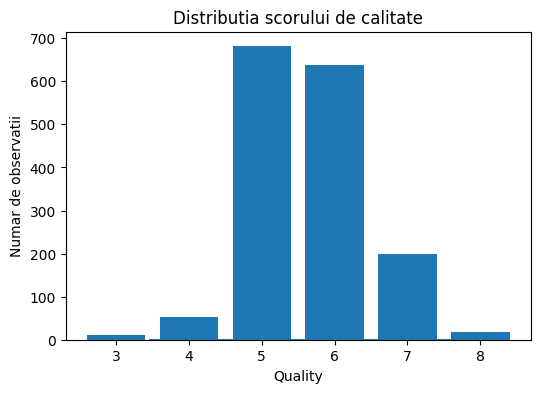

In [10]:
quality_counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(quality_counts.index, quality_counts.values)
plt.title("Distributia scorului de calitate")
plt.xlabel("Quality")
plt.ylabel("Numar de observatii")
plt.savefig("../results/eda_quality.png", bbox_inches="tight", dpi=300)
plt.show()

### Interpretarea distribuției variabilei țintă

Se observă că cele mai multe observații au scoruri de calitate în zona medie, în special valorile 5 și 6. Valorile extreme, precum 3 sau 8, apar mult mai rar.

Acest lucru indică faptul că setul de date este dezechilibrat din punctul de vedere al distribuției scorurilor de calitate, deoarece majoritatea vinurilor sunt evaluate cu scoruri medii.

Pentru problema de regresie, această distribuție este importantă deoarece modelul va învăța mai bine valorile frecvente și poate avea dificultăți în prezicerea scorurilor rare.

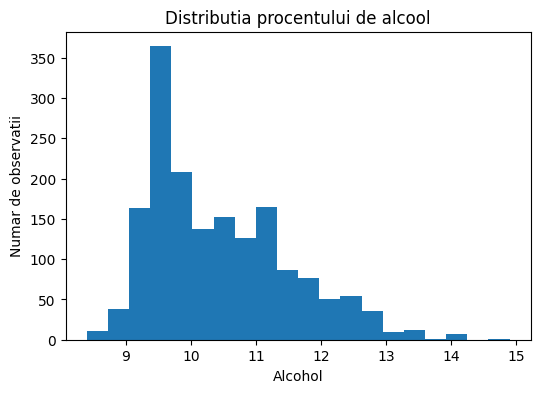

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["alcohol"], bins=20)
plt.title("Distributia procentului de alcool")
plt.xlabel("Alcohol")
plt.ylabel("Numar de observatii")
plt.savefig("../results/eda_alcohol.png", bbox_inches="tight", dpi=300)
plt.show()

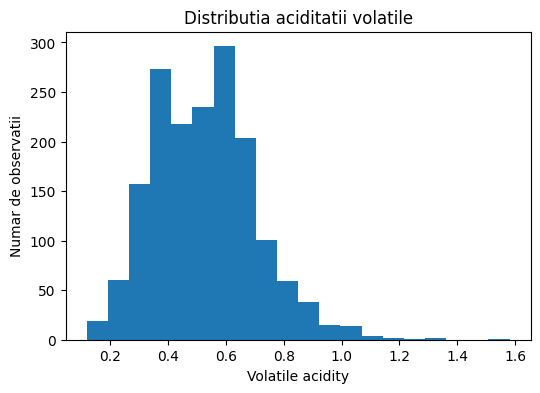

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["volatile acidity"], bins=20)
plt.title("Distributia aciditatii volatile")
plt.xlabel("Volatile acidity")
plt.ylabel("Numar de observatii")
plt.savefig("../results/eda_volatile_acidity.png", bbox_inches="tight", dpi=300)
plt.show()

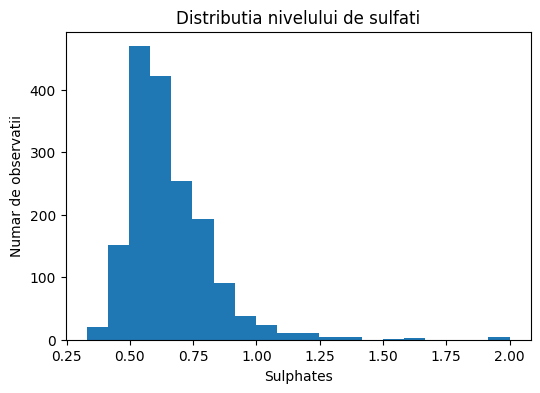

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["sulphates"], bins=20)
plt.title("Distributia nivelului de sulfati")
plt.xlabel("Sulphates")
plt.ylabel("Numar de observatii")
plt.savefig("../results/eda_sulphates.png", bbox_inches="tight", dpi=300)
plt.show()

### Interpretarea distribuției caracteristicilor analizate

Au fost analizate distribuțiile pentru câteva caracteristici relevante din setul de date: 'alcohol', 'volatile acidity' și 'sulphates'.

Pentru caracteristica 'alcohol', se observă că majoritatea valorilor sunt concentrate în zona 9-11, iar valorile mai mari, apropiate de 14-15, apar mai rar. Această variabilă poate fi importantă pentru predicția calității vinului, deoarece procentul de alcool poate influența scorul final al calității.

Pentru caracteristica 'volatile acidity', valorile sunt concentrate mai ales în zona valorilor mici și medii, iar valorile foarte mari sunt mai rare.

Pentru caracteristica 'sulphates', majoritatea valorilor sunt concentrate într-un interval redus, iar valorile foarte mari apar rar.

În ansamblu, distribuțiile acestor caracteristici arată că datele nu sunt perfect uniforme și că există variabile cu valori mai concentrate în anumite intervale. Acest lucru poate influența modul în care modelele de regresie învață relația dintre caracteristici și scorul final.

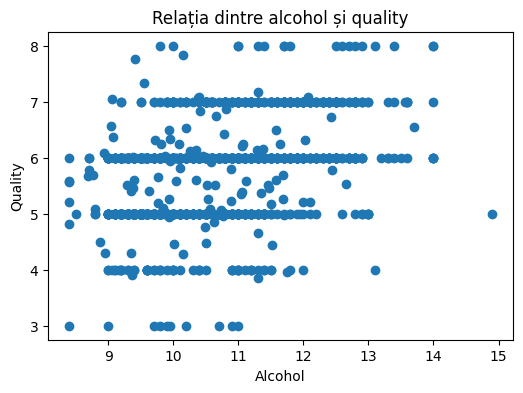

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df["alcohol"], df["quality"])
plt.title("Relația dintre alcohol și quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.savefig("../results/eda_alcohol_quality.png", bbox_inches="tight", dpi=300)
plt.show()

### Interpretarea relației dintre 'alcohol' și 'quality'

Graficul prezintă relația dintre procentul de alcool și scorul de calitate al vinului.

Se poate observa că vinurile cu un procent mai mare de alcool tind, în general, să aibă scoruri de calitate mai ridicate. Totuși, relația nu este perfect liniară, deoarece pentru aceleași valori ale procentului de alcool pot exista mai multe scoruri de calitate.

Această observație sugerează că 'alcohol' poate fi o caracteristică relevantă pentru modelele de regresie, dar nu este suficientă singură pentru a prezice exact calitatea vinului.

## Pregătirea datelor pentru antrenare

În această etapă separăm setul de date în caracteristici de intrare și variabilă țintă.

Pentru problema de regresie, variabila țintă este 'quality', iar celelalte coloane sunt folosite ca variabile de intrare.

In [15]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Dimensiune X:", X.shape)
print("Dimensiune y:", y.shape)

Dimensiune X: (1699, 11)
Dimensiune y: (1699,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Dimensiune X_train:", X_train.shape)
print("Dimensiune X_test:", X_test.shape)
print("Dimensiune y_train:", y_train.shape)
print("Dimensiune y_test:", y_test.shape)

Dimensiune X_train: (1274, 11)
Dimensiune X_test: (425, 11)
Dimensiune y_train: (1274,)
Dimensiune y_test: (425,)


### Interpretarea împărțirii datelor

Datele au fost împărțite în set de antrenare și set de testare. Setul de antrenare conține 1274 de observații și este folosit pentru instruirea modelelor de regresie. Setul de testare conține 425 de observații și este folosit pentru evaluarea performanței modelelor pe date nevăzute în timpul antrenării.

Această împărțire permite verificarea capacității modelelor de a generaliza pe exemple noi.

## Antrenarea și evaluarea modelelor de bază

În această etapă sunt antrenate mai multe modele de regresie folosind setările implicite ale hiperparametrilor.

Modelele vor fi evaluate pe setul de testare folosind următoarele metrici:

    - MSE - Mean Squared Error;
    - MAE - Mean Absolute Error;
    - RMSE - Root Mean Squared Error;
    - R² - coeficientul de determinare.

Pentru MSE, MAE și RMSE, valori mai mici indică o performanță mai bună. Pentru R², valori mai apropiate de 1 indică o performanță mai bună.

### Model 1: Linear Regression

Primul model antrenat este Linear Regression. Acesta este un model simplu de regresie, folosit ca punct de referință pentru comparația cu modelele mai complexe. 

In [17]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print("MSE:", lr_mse)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MSE: 0.4506044001597376
MAE: 0.527262833360457
RMSE: 0.6712707353666906
R2: 0.2893647683779462


### Interpretarea rezultatului pentru Linear Regression

Modelul Linear Regression a obținut un MSE de aproximativ 0.450, un MAE de aproximativ 0.527, un RMSE de aproximativ 0.671 și un scor R2 de aproximativ 0.289.

Valoarea MAE arată că, în medie, predicțiile modelului diferă față de valorile reale ale variabilei quality cu aproximativ 0.52 puncte. RMSE-ul este puțin mai mare, deoarece penalizează mai puternic erorile mai mari.

Scorul R2 indică faptul că modelul explică doar o parte redusă din variația scorului de calitate. Acest lucru sugerează că relația dintre caracteristicile vinului și scorul 'quality' nu este complet liniară.

### Model 2: Decision Tree Regressor

Al doilea model antrenat este Decision Tree Regressor. Acesta este un model bazat pe arbori de decizie, care împarte datele în funcție de valorile caracteristicilor pentru a prezice valoarea variabilei țintă.

Spre deosebire de Linear Regression, acest model poate surprinde relații neliniare între caracteristici și calitatea vinului.

In [18]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("MSE:", dt_mse)
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

MSE: 0.67430261769581
MAE: 0.5027265686124055
RMSE: 0.8211593132247907
R2: -0.06342325272400928


### Interpretarea rezultatului pentru Decision Tree Regressor

Modelul Decision Tree Regressor a obținut un MSE de aproximativ 0.674, un MAE de aproximativ 0.502, un RMSE de aproximativ 0.821 și un scor R2 de aproximativ -0.063.

Scorul R2 negativ arată că modelul are o performanță slabă pe setul de testare. Un R2 negativ înseamnă că modelul generalizează mai slab decât o predicție simplă bazată pe media valorilor reale.

Deși Decision Tree Regressor poate surprinde relații neliniare, în acest caz modelul de bază pare să facă overfitting pe datele de antrenare și nu reușește să generalizeze bine pe datele de testare.

### Model 3: Random Forest Regressor

Al treilea model antrenat este Random Forest Regressor. Acesta este un model format din mai mulți arbori de decizie.

Spre deosebire de un singur arbore de decizie, Random Forest combină predicțiile mai multor arbori, ceea ce poate reduce overfitting-ul și poate îmbunătăți capacitatea de generalizare.

In [19]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MSE: 0.38181372307309575
MAE: 0.4524794277271806
RMSE: 0.6179107727440069
R2: 0.3978525654957151


### Interpretarea rezultatului pentru Random Forest Regressor

Modelul Random Forest Regressor a obținut un MSE de aproximativ 0.381, un MAE de aproximativ 0.452, un RMSE de aproximativ 0.617 și un scor R2 de aproximativ 0.397.

Comparativ cu Linear Regression și Decision Tree Regressor, modelul Random Forest obține rezultate mai bune. MSE și RMSE sunt mai mici, ceea ce arată că erorile de predicție sunt mai reduse. Scorul R2 obținut sugerează că folosirea mai multor arbori de decizie ajută la obținerea unei generalizări mai bune.

Prin urmare, Random Forest Regressor este un model de bază mai performant decât Linear Regression și Decision Tree Regressor pentru acest set de date.

### Model 4: Support Vector Regressor

Al patrulea model antrenat este Support Vector Regressor. Modelul încearcă să găsească o funcție care aproximează cât mai bine valorile reale, tolerând o anumită eroare în jurul predicției.

In [20]:
svr_model = SVR()

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)

print("MSE:", svr_mse)
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)

MSE: 0.546068060821505
MAE: 0.5654407282387203
RMSE: 0.7389641810138736
R2: 0.13881177648125065


### Interpretarea rezultatului pentru Support Vector Regressor

Modelul Support Vector Regressor a obținut un MSE de aproximativ 0.546, un MAE de aproximativ 0.565, un RMSE de aproximativ 0.739 și un scor R2 de aproximativ 0.138.

Comparativ cu Random Forest Regressor, Support Vector Regressor are o performanță mai slabă pe acest set de date. Un motiv posibil este faptul că SVR este sensibil la scala caracteristicilor, iar în această etapă modelul a fost antrenat cu setările implicite, fără ajustarea hiperparametrilor și fără scalare suplimentară.

### Model 5: K-Nearest Neighbors Regressor

Al cincilea model antrenat este K-Nearest Neighbors Regressor. Acesta prezice valoarea variabilei țintă pe baza celor mai apropiați vecini din setul de antrenare.

Pentru regresie, predicția este calculată de obicei ca media valorilor țintă ale celor mai apropiați vecini.

In [21]:
knn_model = KNeighborsRegressor()

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, y_pred_knn)

print("MSE:", knn_mse)
print("MAE:", knn_mae)
print("RMSE:", knn_rmse)
print("R2:", knn_r2)

MSE: 0.6052600938218536
MAE: 0.5891585115259551
RMSE: 0.7779846359805916
R2: 0.04546172471417642


### Interpretarea rezultatului pentru K-Nearest Neighbors Regressor

Modelul K-Nearest Neighbors Regressor a obținut un MSE de aproximativ 0.605, un MAE de aproximativ 0.589, un RMSE de aproximativ 0.777 și un scor R2 de aproximativ 0.045.

Performanța slabă poate fi explicată prin faptul că KNN este sensibil la scala caracteristicilor. Deoarece în această etapă folosim modelul de bază, fără scalare și fără ajustarea hiperparametrilor, rezultatul nu este foarte bun.

### Model 6: Gaussian Process Regressor

Al șaselea model antrenat este Gaussian Process Regressor. Acesta este un model de regresie probabilistic, care poate estima relații complexe între caracteristicile de intrare și variabila țintă.

In [22]:
gp_model = GaussianProcessRegressor()

gp_model.fit(X_train, y_train)

y_pred_gp = gp_model.predict(X_test)

gp_mse = mean_squared_error(y_test, y_pred_gp)
gp_mae = mean_absolute_error(y_test, y_pred_gp)
gp_rmse = np.sqrt(gp_mse)
gp_r2 = r2_score(y_test, y_pred_gp)

print("MSE:", gp_mse)
print("MAE:", gp_mae)
print("RMSE:", gp_rmse)
print("R2:", gp_r2)

MSE: 12.49049007330014
MAE: 2.729161385618031
RMSE: 3.534188743304486
R2: -18.69839243284361


### Interpretarea rezultatului pentru Gaussian Process Regressor

Modelul Gaussian Process Regressor a obținut un MSE de aproximativ 12.490, un MAE de aproximativ 2.729, un RMSE de aproximativ 3.534 și un scor R2 de aproximativ -18.698.

Aceste valori indică o performanță foarte slabă pe setul de testare. MAE-ul arată că, în medie, predicțiile diferă de valorile reale ale variabilei 'quality' cu aproximativ 2.73 puncte, ceea ce este mult pentru un scor de calitate cu valori între 3 și 8.

Prin urmare, Gaussian Process Regressor nu este un model performant în forma de bază pentru acest set de date.

### Model 7: XGBoost Regressor

Al șaptelea model antrenat este XGBoost Regressor. Modelul construiește arbori succesivi, fiecare încercând să corecteze erorile făcute de arborii anteriori. Din acest motiv, XGBoost poate obține performanțe bune pe probleme de regresie cu relații neliniare între caracteristici și variabila țintă.

In [23]:
xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("MSE:", xgb_mse)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

MSE: 0.39933147081385834
MAE: 0.4438381366980874
RMSE: 0.6319267922899442
R2: 0.37022582967413753


### Interpretarea rezultatului pentru XGBoost Regressor

Modelul XGBoost Regressor a obținut un MSE de aproximativ 0.399, un MAE de aproximativ 0.443, un RMSE de aproximativ 0.631 și un scor R2 de aproximativ 0.370.

Comparativ cu Linear Regression, Decision Tree Regressor, Support Vector Regressor, K-Nearest Neighbors Regressor și Gaussian Process Regressor, modelul XGBoost obține rezultate mai bune. Totuși, comparativ cu Random Forest Regressor, performanța este apropiată, dar ușor mai slabă după scorul R2 și RMSE.

### Model 8: CatBoost Regressor

Al optulea model antrenat este CatBoost Regressor. CatBoost construiește mai mulți arbori succesivi și încearcă să reducă erorile făcute de modelele anterioare.

In [24]:
cat_model = CatBoostRegressor(random_state=42, verbose=0)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

cat_mse = mean_squared_error(y_test, y_pred_cat)
cat_mae = mean_absolute_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_test, y_pred_cat)

print("MSE:", cat_mse)
print("MAE:", cat_mae)
print("RMSE:", cat_rmse)
print("R2:", cat_r2)

MSE: 0.36663186186245644
MAE: 0.44130358800208985
RMSE: 0.605501331016255
R2: 0.4217954418947294


### Interpretarea rezultatului pentru CatBoost Regressor

Modelul CatBoost Regressor a obținut un MSE de aproximativ 0.366, un MAE de aproximativ 0.441, un RMSE de aproximativ 0.605 și un scor R2 de aproximativ 0.421.

Comparativ cu modelele anterioare, CatBoost Regressor are cea mai bună performanță de până acum, având cel mai mic MSE, cel mai mic RMSE și cel mai mare scor R2.

### Model 9: Explainable Boosting Regressor

Al nouălea model antrenat este Explainable Boosting Regressor. Acesta este un model de tip boosting interpretabil, care încearcă să combine performanța modelelor complexe cu o interpretabilitate mai bună.

In [25]:
ebr_model = ExplainableBoostingRegressor(random_state=42)

ebr_model.fit(X_train, y_train)

y_pred_ebr = ebr_model.predict(X_test)

ebr_mse = mean_squared_error(y_test, y_pred_ebr)
ebr_mae = mean_absolute_error(y_test, y_pred_ebr)
ebr_rmse = np.sqrt(ebr_mse)
ebr_r2 = r2_score(y_test, y_pred_ebr)

print("MSE:", ebr_mse)
print("MAE:", ebr_mae)
print("RMSE:", ebr_rmse)
print("R2:", ebr_r2)

MSE: 0.416696720779934
MAE: 0.5083787718651224
RMSE: 0.6455205037641594
R2: 0.3428395937043103


### Interpretarea rezultatului pentru Explainable Boosting Regressor

Modelul Explainable Boosting Regressor a obținut un MSE de aproximativ 0.416, un MAE de aproximativ 0.508, un RMSE de aproximativ 0.645 și un scor R2 de aproximativ 0.342.

Comparativ cu modelele testate anterior, Explainable Boosting Regressor are o performanță mai bună decât Linear Regression, Decision Tree Regressor, SVR, KNN și Gaussian Process Regressor, dar este mai slab decât Random Forest, XGBoost și CatBoost.

## Compararea modelelor de bază

După antrenarea tuturor modelelor de regresie, rezultatele sunt centralizate într-un tabel pentru a putea compara performanțele obținute.

Pentru metricile MSE, MAE și RMSE, valorile mai mici indică o performanță mai bună. Pentru R2, valorile mai mari indică o performanță mai bună.

In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Support Vector Regressor",
        "K-Nearest Neighbors Regressor",
        "Gaussian Process Regressor",
        "XGBoost Regressor",
        "CatBoost Regressor",
        "Explainable Boosting Regressor"
    ],
    "MSE": [
        lr_mse,
        dt_mse,
        rf_mse,
        svr_mse,
        knn_mse,
        gp_mse,
        xgb_mse,
        cat_mse,
        ebr_mse
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        svr_mae,
        knn_mae,
        gp_mae,
        xgb_mae,
        cat_mae,
        ebr_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse,
        knn_rmse,
        gp_rmse,
        xgb_rmse,
        cat_rmse,
        ebr_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2,
        svr_r2,
        knn_r2,
        gp_r2,
        xgb_r2,
        cat_r2,
        ebr_r2
    ]
})

results

,Model,MSE,MAE,RMSE,R2
0,Linear Regression,0.450604,0.527263,0.671271,0.289365
1,Decision Tree Regressor,0.674303,0.502727,0.821159,-0.063423
2,Random Forest Regressor,0.381814,0.452479,0.617911,0.397853
3,Support Vector Regressor,0.546068,0.565441,0.738964,0.138812
4,K-Nearest Neighbors Regressor,0.605260,0.589159,0.777985,0.045462
5,Gaussian Process Regressor,12.490490,2.729161,3.534189,-18.698392
6,XGBoost Regressor,0.399331,0.443838,0.631927,0.370226
7,CatBoost Regressor,0.366632,0.441304,0.605501,0.421795
8,Explainable Boosting Regressor,0.416697,0.508379,0.645521,0.342840


In [27]:
results_sorted = results.sort_values(by="R2", ascending=False)
results_sorted

,Model,MSE,MAE,RMSE,R2
7,CatBoost Regressor,0.366632,0.441304,0.605501,0.421795
2,Random Forest Regressor,0.381814,0.452479,0.617911,0.397853
6,XGBoost Regressor,0.399331,0.443838,0.631927,0.370226
8,Explainable Boosting Regressor,0.416697,0.508379,0.645521,0.342840
0,Linear Regression,0.450604,0.527263,0.671271,0.289365
3,Support Vector Regressor,0.546068,0.565441,0.738964,0.138812
4,K-Nearest Neighbors Regressor,0.605260,0.589159,0.777985,0.045462
1,Decision Tree Regressor,0.674303,0.502727,0.821159,-0.063423
5,Gaussian Process Regressor,12.490490,2.729161,3.534189,-18.698392


In [28]:
top_models = results_sorted.head(5)
top_models

,Model,MSE,MAE,RMSE,R2
7,CatBoost Regressor,0.366632,0.441304,0.605501,0.421795
2,Random Forest Regressor,0.381814,0.452479,0.617911,0.397853
6,XGBoost Regressor,0.399331,0.443838,0.631927,0.370226
8,Explainable Boosting Regressor,0.416697,0.508379,0.645521,0.342840
0,Linear Regression,0.450604,0.527263,0.671271,0.289365


### Interpretarea comparației modelelor de bază

Modelele au fost sortate descrescător după scorul R2, deoarece o valoare mai mare indică o performanță mai bună.

Cel mai bun model de bază este 'CatBoost Regressor', cu cel mai mare scor R2 și cele mai mici erori. Rezultate apropiate sunt obținute și de 'Random Forest Regressor' și 'XGBoost Regressor', ceea ce arată că modelele bazate pe arbori și boosting se potrivesc mai bine acestui set de date.

'Explainable Boosting Regressor' are o performanță medie, iar 'Linear Regression', deși intră în primele 5 modele, este mai slab decât modelele neliniare.

## Ajustarea hiperparametrilor

În această etapă sunt ajustați hiperparametrii pentru primele 5 modele selectate în urma comparării modelelor de bază.

Modelele selectate sunt:

    - 'CatBoost Regressor'
    - 'Random Forest Regressor'
    - 'XGBoost Regressor'
    - 'Explainable Boosting Regressor'
    - 'Linear Regression'

Pentru ajustare se folosește GridSearchCV, iar performanța este evaluată pe baza scorului R2. Scopul este găsirea combinației de hiperparametri care oferă cea mai bună performanță pe datele de validare.

### Ajustarea hiperparametrilor pentru CatBoost Regressor

Primul model optimizat este 'CatBoost Regressor', deoarece a obținut cea mai bună performanță dintre modelele de bază.

Pentru acest model se testează mai multe valori pentru hiperparametri precum 'iterations', 'depth' și 'learning_rate'.

In [29]:
cat_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

cat_grid = GridSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0),
    param_grid=cat_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...42, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6], 'iterations': [100, 200], 'learning_rate': [0.05, 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [30]:
print("Cei mai buni hiperparametri:")
print(cat_grid.best_params_)

print("Cel mai bun scor R2:")
print(cat_grid.best_score_)

Cei mai buni hiperparametri:
{'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
Cel mai bun scor R2:
0.40276435211918205


### Interpretarea ajustării hiperparametrilor pentru CatBoost Regressor

Cei mai buni hiperparametri obținuți sunt:

    - 'depth' = 6
    - 'iterations' = 200
    - 'learning_rate' = 0.1

Cel mai bun scor R2 obținut în etapa de validare este aproximativ 0.402.

Acest rezultat arată că modelul CatBoost optimizat are o capacitate bună de a surprinde relațiile dintre caracteristicile chimice ale vinului și scorul 'quality'.

In [31]:
best_cat_model = cat_grid.best_estimator_

y_train_pred_cat = best_cat_model.predict(X_train)
y_test_pred_cat = best_cat_model.predict(X_test)

train_r2_cat = r2_score(y_train, y_train_pred_cat)
test_r2_cat = r2_score(y_test, y_test_pred_cat)

print("R2 pe train:", train_r2_cat)
print("R2 pe test:", test_r2_cat)

R2 pe train: 0.7842394127573284
R2 pe test: 0.3866684277961735


### Verificare overfitting pentru CatBoost Regressor

Modelul CatBoost optimizat a obținut un scor R2 de aproximativ 0.784 pe setul de antrenare și un scor R2 de aproximativ 0.386 pe setul de testare.

Se observă că scorul pe setul de antrenare este mult mai mare decât scorul pe setul de testare. Acest lucru indică faptul că modelul învață foarte bine datele de antrenare, dar nu generalizează la fel de bine pe date nevăzute.

Diferența dintre cele două scoruri sugerează un posibil overfitting.

In [32]:
best_cat_mse = mean_squared_error(y_test, y_test_pred_cat)
best_cat_mae = mean_absolute_error(y_test, y_test_pred_cat)
best_cat_rmse = np.sqrt(best_cat_mse)
best_cat_r2 = r2_score(y_test, y_test_pred_cat)

print("MSE:", best_cat_mse)
print("MAE:", best_cat_mae)
print("RMSE:", best_cat_rmse)
print("R2:", best_cat_r2)

MSE: 0.38890543684571965
MAE: 0.47976369597633434
RMSE: 0.6236228322036643
R2: 0.3866684277961735


### Rezultatele pentru CatBoost Regressor optimizat

Comparativ cu varianta de bază a modelului CatBoost, rezultatul optimizat nu este mai bun pe setul de testare. Modelul de bază avea un R2 mai mare, aproximativ 0.421, în timp ce modelul optimizat obține aproximativ 0.386.

Acest lucru arată că hiperparametrii aleși prin GridSearchCV au avut un scor bun în validare, dar nu au îmbunătățit performanța pe setul de testare.

### Ajustarea hiperparametrilor pentru Random Forest Regressor

Al doilea model optimizat este 'Random Forest Regressor'. Pentru acest model se testează mai multe valori pentru hiperparametri precum 'n_estimators', 'max_depth' și 'min_samples_split'.

In [33]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [34]:
print("Cei mai buni hiperparametri:")
print(rf_grid.best_params_)

print("Cel mai bun scor R2:")
print(rf_grid.best_score_)

Cei mai buni hiperparametri:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Cel mai bun scor R2:
0.4365292380717861


### Interpretarea ajustării hiperparametrilor pentru Random Forest Regressor

Cei mai buni hiperparametri obținuți au fost:

    - 'max_depth' = None
    - 'min_samples_split' = 2
    - 'n_estimators' = 200

Cel mai bun scor R2 obținut în etapa de validare a fost aproximativ 0.436.

Acest rezultat este mai bun decât scorul obținut în validare de CatBoost optimizat, ceea ce arată că Random Forest poate fi un candidat foarte bun pentru modelul final.

In [35]:
best_rf_model = rf_grid.best_estimator_

y_train_pred_rf = best_rf_model.predict(X_train)
y_test_pred_rf = best_rf_model.predict(X_test)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("R2 pe train:", train_r2_rf)
print("R2 pe test:", test_r2_rf)

R2 pe train: 0.9241128253121066
R2 pe test: 0.41182109551588264


### Verificare overfitting pentru Random Forest Regressor

Modelul Random Forest optimizat a obținut un scor R2 de aproximativ 0.924 pe setul de antrenare și un scor R2 de aproximativ 0.411 pe setul de testare.

Se observă că scorul pe setul de antrenare este mult mai mare decât scorul pe setul de testare. Acest lucru indică faptul că modelul se potrivește foarte bine pe datele de antrenare, dar generalizează mai slab pe datele nevăzute. Diferența dintre cele două scoruri sugerează un posibil overfitting.

In [36]:
best_rf_mse = mean_squared_error(y_test, y_test_pred_rf)
best_rf_mae = mean_absolute_error(y_test, y_test_pred_rf)
best_rf_rmse = np.sqrt(best_rf_mse)
best_rf_r2 = r2_score(y_test, y_test_pred_rf)

print("MSE:", best_rf_mse)
print("MAE:", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R2:", best_rf_r2)

MSE: 0.3729564629616263
MAE: 0.4490934805167131
RMSE: 0.6107016153258695
R2: 0.41182109551588264


### Rezultatele pentru Random Forest Regressor optimizat

Modelul Random Forest optimizat a obținut pe setul de testare un MSE de aproximativ 0.372, un MAE de aproximativ 0.449, un RMSE de aproximativ 0.610 și un scor R2 de aproximativ 0.411.

Comparativ cu varianta de bază a modelului Random Forest, rezultatul optimizat este ușor mai bun. Modelul de bază avea un scor R2 de aproximativ 0.397, iar modelul optimizat obține un scor R2 de aproximativ 0.411.

Acest lucru arată că ajustarea hiperparametrilor a îmbunătățit performanța modelului pe setul de testare.

### Ajustarea hiperparametrilor pentru XGBoost Regressor

Al treilea model optimizat este 'XGBoost Regressor'. Pentru acest model se testează mai multe valori pentru hiperparametri precum 'n_estimators', 'max_depth' și 'learning_rate'.

In [37]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [38]:
print("Cei mai buni hiperparametri:")
print(xgb_grid.best_params_)

print("Cel mai bun scor R2:")
print(xgb_grid.best_score_)

Cei mai buni hiperparametri:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Cel mai bun scor R2:
0.38423826318226284


### Interpretarea ajustării hiperparametrilor pentru XGBoost Regressor

Cei mai buni hiperparametri obținuți au fost:

    - 'learning_rate' = 0.05
    - 'max_depth' = 5
    - 'n_estimators' = 100

Cel mai bun scor R2 obținut în etapa de validare a fost aproximativ 0.384.

In [39]:
best_xgb_model = xgb_grid.best_estimator_

y_train_pred_xgb = best_xgb_model.predict(X_train)
y_test_pred_xgb = best_xgb_model.predict(X_test)

train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)

print("R2 pe train:", train_r2_xgb)
print("R2 pe test:", test_r2_xgb)

R2 pe train: 0.7525073595049152
R2 pe test: 0.37213656003070184


### Verificare overfitting pentru XGBoost Regressor

Modelul XGBoost optimizat a obținut un scor R2 de aproximativ 0.752 pe setul de antrenare și un scor R2 de aproximativ 0.372 pe setul de testare.

Diferența dintre cele două scoruri sugerează un posibil overfitting. Totuși, scorul R2 pe test este apropiat de rezultatul obținut anterior de modelul XGBoost de bază, deci modelul rămâne relevant pentru comparația finală.

In [40]:
best_xgb_mse = mean_squared_error(y_test, y_test_pred_xgb)
best_xgb_mae = mean_absolute_error(y_test, y_test_pred_xgb)
best_xgb_rmse = np.sqrt(best_xgb_mse)
best_xgb_r2 = r2_score(y_test, y_test_pred_xgb)

print("MSE:", best_xgb_mse)
print("MAE:", best_xgb_mae)
print("RMSE:", best_xgb_rmse)
print("R2:", best_xgb_r2)

MSE: 0.3981199019697111
MAE: 0.4851424955937662
RMSE: 0.6309674333669775
R2: 0.37213656003070184


### Rezultatele pentru XGBoost Regressor optimizat

Modelul XGBoost optimizat a obținut pe setul de testare un MSE de aproximativ 0.398, un MAE de aproximativ 0.485, un RMSE de aproximativ 0.630 și un scor R2 de aproximativ 0.372.

Comparativ cu varianta de bază a modelului XGBoost, performanța este foarte apropiată. Acest lucru arată că ajustarea hiperparametrilor a adus o îmbunătățire foarte mică pe setul de testare.

### Ajustarea hiperparametrilor pentru Explainable Boosting Regressor

Al patrulea model optimizat este 'Explainable Boosting Regressor'. Pentru acest model se testează mai multe valori pentru hiperparametri precum 'learning_rate', 'max_bins' și 'interactions'.

In [41]:
ebr_param_grid = {
    "learning_rate": [0.01, 0.05],
    "max_bins": [128, 256],
    "interactions": [0, 5]
}

ebr_grid = GridSearchCV(
    estimator=ExplainableBoostingRegressor(random_state=42),
    param_grid=ebr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ebr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExplainableBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'interactions': [0, 5], 'learning_rate': [0.01, 0.05], 'max_bins': [128, 256]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [42]:
print("Cei mai buni hiperparametri:")
print(ebr_grid.best_params_)

print("Cel mai bun scor R2:")
print(ebr_grid.best_score_)

Cei mai buni hiperparametri:
{'interactions': 5, 'learning_rate': 0.05, 'max_bins': 256}
Cel mai bun scor R2:
0.3650079243397232


### Interpretarea ajustării hiperparametrilor pentru Explainable Boosting Regressor

Cei mai buni hiperparametri obținuți au fost:

    - 'interactions' = 5
    - 'learning_rate' = 0.05
    - 'max_bins' = 256

Cel mai bun scor R2 obținut în etapa de validare a fost aproximativ 0.365.

In [43]:
best_ebr_model = ebr_grid.best_estimator_

y_train_pred_ebr = best_ebr_model.predict(X_train)
y_test_pred_ebr = best_ebr_model.predict(X_test)

train_r2_ebr = r2_score(y_train, y_train_pred_ebr)
test_r2_ebr = r2_score(y_test, y_test_pred_ebr)

print("R2 pe train:", train_r2_ebr)
print("R2 pe test:", test_r2_ebr)

R2 pe train: 0.46768130791859486
R2 pe test: 0.34477937501191414


### Verificare overfitting pentru Explainable Boosting Regressor

Modelul Explainable Boosting Regressor optimizat a obținut un scor R2 de aproximativ 0.467 pe setul de antrenare și un scor R2 de aproximativ 0.344 pe setul de testare.

Diferența dintre cele două scoruri nu este la fel de mare ca în cazul modelelor CatBoost, Random Forest sau XGBoost optimizate. Acest lucru sugerează că modelul Explainable Boosting Regressor prezintă un risc mai redus de overfitting.

In [44]:
best_ebr_mse = mean_squared_error(y_test, y_test_pred_ebr)
best_ebr_mae = mean_absolute_error(y_test, y_test_pred_ebr)
best_ebr_rmse = np.sqrt(best_ebr_mse)
best_ebr_r2 = r2_score(y_test, y_test_pred_ebr)

print("MSE:", best_ebr_mse)
print("MAE:", best_ebr_mae)
print("RMSE:", best_ebr_rmse)
print("R2:", best_ebr_r2)

MSE: 0.41546673111201565
MAE: 0.5107928679793041
RMSE: 0.6445670881390204
R2: 0.34477937501191414


### Rezultatele pentru Explainable Boosting Regressor optimizat

Modelul Explainable Boosting Regressor optimizat a obținut pe setul de testare un MSE de aproximativ 0.415, un MAE de aproximativ 0.510, un RMSE de aproximativ 0.644 și un scor R2 de aproximativ 0.344.

Comparativ cu varianta de bază, rezultatul este foarte apropiat. Acest lucru arată că ajustarea hiperparametrilor a adus o îmbunătățire foarte mică pe setul de testare.

### Ajustarea hiperparametrilor pentru Linear Regression

Al cincilea model optimizat este 'Linear Regression'. Pentru acest model se testează parametrul 'fit_intercept', care stabilește dacă modelul calculează sau nu termenul liber al ecuației liniare.

In [45]:
lr_param_grid = {
    "fit_intercept": [True, False]
}

lr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [46]:
print("Cei mai buni hiperparametri:")
print(lr_grid.best_params_)

print("Cel mai bun scor R2:")
print(lr_grid.best_score_)

Cei mai buni hiperparametri:
{'fit_intercept': True}
Cel mai bun scor R2:
0.3249658944346915


### Interpretarea ajustării hiperparametrilor pentru Linear Regression

Cel mai bun hiperparametru obținut a fost:

    - 'fit_intercept' = True

Cel mai bun scor R2 obținut în etapa de validare a fost aproximativ 0.324.

In [47]:
best_lr_model = lr_grid.best_estimator_

y_train_pred_lr = best_lr_model.predict(X_train)
y_test_pred_lr = best_lr_model.predict(X_test)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("R2 pe train:", train_r2_lr)
print("R2 pe test:", test_r2_lr)

R2 pe train: 0.342105723767842
R2 pe test: 0.2893647683779462


### Verificare overfitting pentru Linear Regression

Modelul Linear Regression optimizat a obținut un scor R2 de aproximativ 0.342 pe setul de antrenare și un scor R2 de aproximativ 0.289 pe setul de testare.

Se observă că diferența dintre scorul de train și scorul de test este mică. Acest lucru indică faptul că modelul nu prezintă overfitting puternic.

Totuși, ambele scoruri R2 sunt destul de reduse, ceea ce arată că modelul nu reușește să explice foarte bine variația scorului 'quality'.

In [48]:
best_lr_mse = mean_squared_error(y_test, y_test_pred_lr)
best_lr_mae = mean_absolute_error(y_test, y_test_pred_lr)
best_lr_rmse = np.sqrt(best_lr_mse)
best_lr_r2 = r2_score(y_test, y_test_pred_lr)

print("MSE:", best_lr_mse)
print("MAE:", best_lr_mae)
print("RMSE:", best_lr_rmse)
print("R2:", best_lr_r2)

MSE: 0.4506044001597376
MAE: 0.527262833360457
RMSE: 0.6712707353666906
R2: 0.2893647683779462


### Rezultatele pentru Linear Regression optimizat

Modelul Linear Regression optimizat a obținut pe setul de testare un MSE de aproximativ 0.450, un MAE de aproximativ 0.527, un RMSE de aproximativ 0.671 și un scor R2 de aproximativ 0.289.

Rezultatele sunt identice cu cele ale modelului Linear Regression de bază, deoarece cel mai bun hiperparametru ales a fost 'fit_intercept' = True, adică setarea implicită a modelului.

Prin urmare, Linear Regression optimizat este util ca model de referință, dar nu este cel mai potrivit model pentru alegerea finală.

## Compararea modelelor optimizate

După ajustarea hiperparametrilor, cele 5 modele selectate sunt comparate din nou. Scopul acestei comparații este alegerea celui mai bun model final pentru problema de regresie.

In [49]:
h_results = pd.DataFrame({
    "Model": [
        "CatBoost Regressor optimizat",
        "Random Forest Regressor optimizat",
        "XGBoost Regressor optimizat",
        "Explainable Boosting Regressor optimizat",
        "Linear Regression optimizat"
    ],
    "MSE": [
        best_cat_mse,
        best_rf_mse,
        best_xgb_mse,
        best_ebr_mse,
        best_lr_mse
    ],
    "MAE": [
        best_cat_mae,
        best_rf_mae,
        best_xgb_mae,
        best_ebr_mae,
        best_lr_mae
    ],
    "RMSE": [
        best_cat_rmse,
        best_rf_rmse,
        best_xgb_rmse,
        best_ebr_rmse,
        best_lr_rmse
    ],
    "R2": [
        best_cat_r2,
        best_rf_r2,
        best_xgb_r2,
        best_ebr_r2,
        best_lr_r2
    ]
})

h_results_sorted = h_results.sort_values(by="R2", ascending=False)

h_results_sorted

,Model,MSE,MAE,RMSE,R2
1,Random Forest Regressor optimizat,0.372956,0.449093,0.610702,0.411821
0,CatBoost Regressor optimizat,0.388905,0.479764,0.623623,0.386668
2,XGBoost Regressor optimizat,0.398120,0.485142,0.630967,0.372137
3,Explainable Boosting Regressor optimizat,0.415467,0.510793,0.644567,0.344779
4,Linear Regression optimizat,0.450604,0.527263,0.671271,0.289365


### Interpretarea comparației modelelor optimizate

Tabelul comparativ arată performanța celor 5 modele optimizate, sortate descrescător după scorul R2.

Cel mai bun model optimizat este 'Random Forest Regressor', cu un scor R2 de aproximativ 0.411.

'Explainable Boosting Regressor' și 'Linear Regression' obțin rezultate mai slabe comparativ cu modelele bazate pe arbori. Acest lucru sugerează că relațiile dintre caracteristicile vinului și scorul 'quality' sunt mai bine surprinse de modele neliniare.

Prin urmare, modelul final ales pentru problema de regresie este 'Random Forest Regressor optimizat', deoarece are cel mai bun scor R2 și cele mai bune valori generale ale erorilor dintre modelele optimizate.

## Curbele de învățare

În această etapă sunt analizate curbele de învățare pentru modelele optimizate.

Curbele de învățare arată evoluția scorului obținut pe setul de antrenare și pe setul de validare, în funcție de numărul de exemple folosite la antrenare.

Această analiză ajută la identificarea unor situații de overfitting sau underfitting. Dacă scorul de antrenare este mult mai mare decât scorul de validare, modelul poate prezenta overfitting. Dacă ambele scoruri sunt reduse, modelul poate prezenta underfitting.

In [50]:
def plot_learning_curve(model, model_name, X, y, save_path=None):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    validation_mean = np.mean(validation_scores, axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Scor antrenare")
    plt.plot(train_sizes, validation_mean, marker="o", label="Scor validare")
    plt.title("Curba de invatare - " + model_name)
    plt.xlabel("Numar exemple antrenare")
    plt.ylabel("R2")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

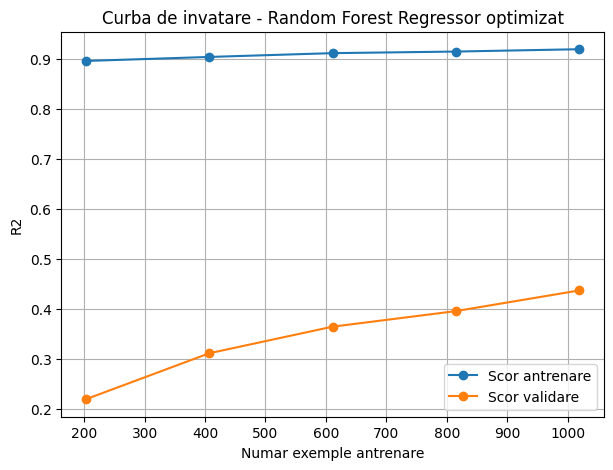

In [51]:
plot_learning_curve(best_rf_model, "Random Forest Regressor optimizat", X_train, y_train, "../results/learning_curve_rf_regressor.png")

### Interpretarea curbei de învățare pentru Random Forest Regressor optimizat

Curba de învățare pentru Random Forest Regressor optimizat arată că scorul R2 pe setul de antrenare este foarte ridicat și rămâne aproape constant pe măsură ce numărul de exemple crește. Scorul de validare este mai mic, dar crește treptat odată cu adăugarea mai multor date de antrenare. 

Diferența dintre scorul de antrenare și scorul de validare rămâne vizibilă, ceea ce indică un posibil overfitting. Totuși, faptul că scorul de validare crește constant sugerează că modelul poate performa mai bine dacă ar avea mai multe date disponibile.

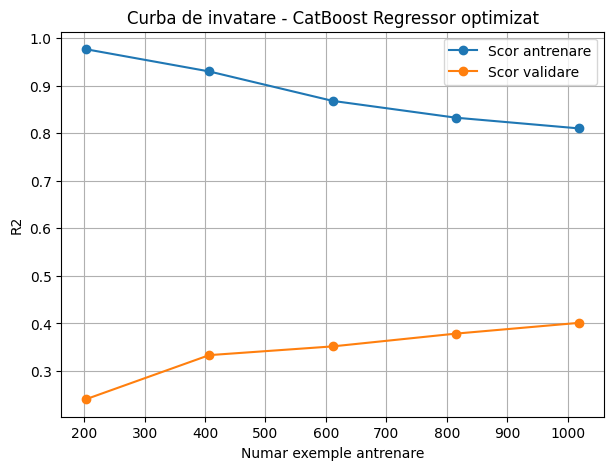

In [52]:
plot_learning_curve(best_cat_model, "CatBoost Regressor optimizat", X_train, y_train, "../results/learning_curve_cat_regressor.png")

### Interpretarea curbei de învățare pentru CatBoost Regressor optimizat

Curba de învățare pentru CatBoost Regressor optimizat arată că scorul R2 pe setul de antrenare este foarte ridicat la început, apoi scade treptat pe măsură ce numărul de exemple de antrenare crește.

Nu se observă underfitting, deoarece scorul de antrenare este ridicat, iar modelul are capacitatea de a învăța relațiile din date. Problema principală observată este diferența dintre scorul de antrenare și scorul de validare, ceea ce indică mai degrabă overfitting decât underfitting.

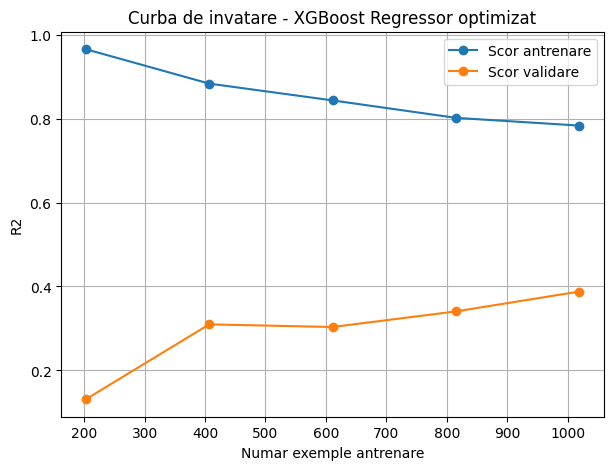

In [54]:
plot_learning_curve(best_xgb_model, "XGBoost Regressor optimizat", X_train, y_train, "../results/learning_curve_xgb_regressor.png")

### Interpretarea curbei de învățare pentru XGBoost Regressor optimizat

Curba de învățare pentru XGBoost Regressor optimizat arată că scorul R2 pe setul de antrenare este ridicat, dar scade treptat pe măsură ce numărul de exemple de antrenare crește.

Nu se observă underfitting, deoarece scorul de antrenare este ridicat. Problema principală este diferența dintre train și validare, deci comportamentul indică mai degrabă overfitting decât underfitting.

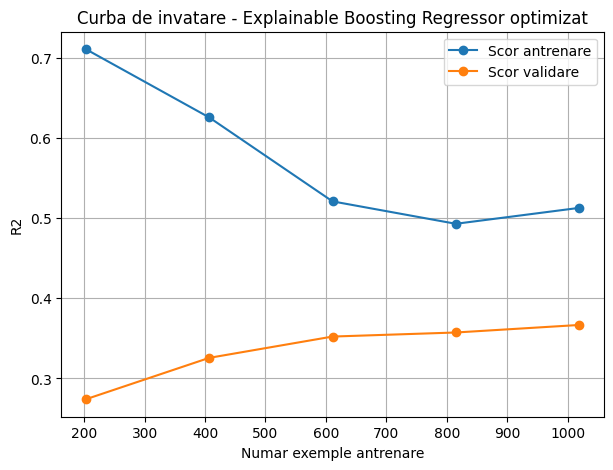

In [55]:
plot_learning_curve(best_ebr_model, "Explainable Boosting Regressor optimizat", X_train, y_train, "../results/learning_curve_ebr_regressor.png")

### Interpretarea curbei de învățare pentru Explainable Boosting Regressor optimizat

Curba de învățare pentru Explainable Boosting Regressor optimizat arată că scorul R2 pe setul de antrenare scade pe măsură ce numărul de exemple crește, apoi se stabilizează în jurul valorii de 0.50.

Diferența dintre scorul de antrenare și scorul de validare este vizibilă, dar mai mică decât în cazul unor modele precum Random Forest sau XGBoost. Prin urmare, riscul de overfitting este mai redus.

Nu se observă underfitting puternic, deoarece scorul de antrenare nu este foarte mic. 

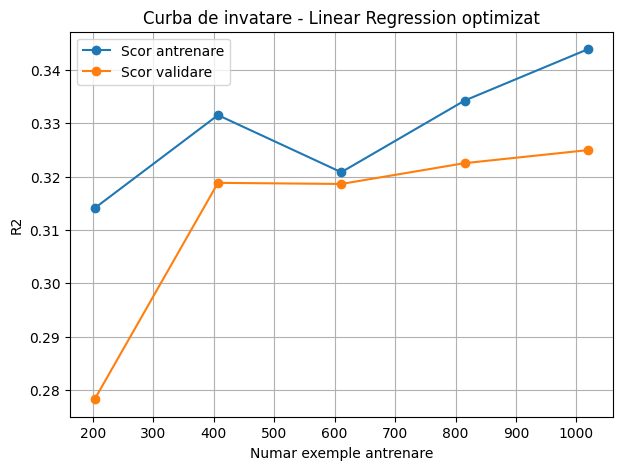

In [56]:
plot_learning_curve(best_lr_model, "Linear Regression optimizat", X_train, y_train, "../results/learning_curve_lr.png")

### Interpretarea curbei de învățare pentru Linear Regression optimizat

Curba de învățare pentru Linear Regression optimizat arată că scorurile R2 pentru antrenare și validare sunt apropiate între ele.

Diferența mică dintre scorul de antrenare și scorul de validare arată că modelul nu prezintă overfitting puternic. Totuși, ambele scoruri sunt destul de mici, ceea ce indică un posibil underfitting, deoarece modelul este prea simplu pentru a surprinde complet relațiile.

### Concluzie privind curbele de învățare

Curbele de învățare au fost analizate pentru cele 5 modele optimizate: Random Forest Regressor, CatBoost Regressor, XGBoost Regressor, Explainable Boosting Regressor și Linear Regression.

Pentru Random Forest, CatBoost și XGBoost se observă scoruri R2 ridicate pe antrenare și scoruri mai mici pe validare, ceea ce sugerează un posibil overfitting. Totuși, scorul de validare crește pe măsură ce numărul de exemple crește, deci modelele pot beneficia de mai multe date.

Explainable Boosting Regressor are o diferență mai mică între train și validare, deci prezintă un risc mai redus de overfitting, dar performanța este mai slabă decât la Random Forest.

Linear Regression are scoruri apropiate între train și validare, deci nu prezintă overfitting puternic. Totuși, valorile R2 sunt reduse, ceea ce indică un posibil underfitting.

În concluzie, Random Forest Regressor optimizat rămâne cel mai bun model după scorul R2 pe test, deși prezintă un posibil overfitting.

## Explicabilitatea și analiza SHAP

În această etapă este analizată explicabilitatea modelelor folosind SHAP.

SHAP ajută la interpretarea predicțiilor unui model, arătând cât de mult contribuie fiecare caracteristică la rezultatul final.

Analiza va fi realizată pentru primele 3 modele optimizate:

1. Random Forest Regressor optimizat
2. CatBoost Regressor optimizat
3. XGBoost Regressor optimizat

Pentru fiecare model vor fi analizate influențele globale ale caracteristicilor, iar pentru modelul final va fi prezentată și o explicație locală pentru o predicție concretă.

In [58]:
explainer_rf = shap.TreeExplainer(best_rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

print("Dimensiune SHAP values:", shap_values_rf.shape)
print("Dimensiune X_test:", X_test.shape)

Dimensiune SHAP values: (425, 11)
Dimensiune X_test: (425, 11)


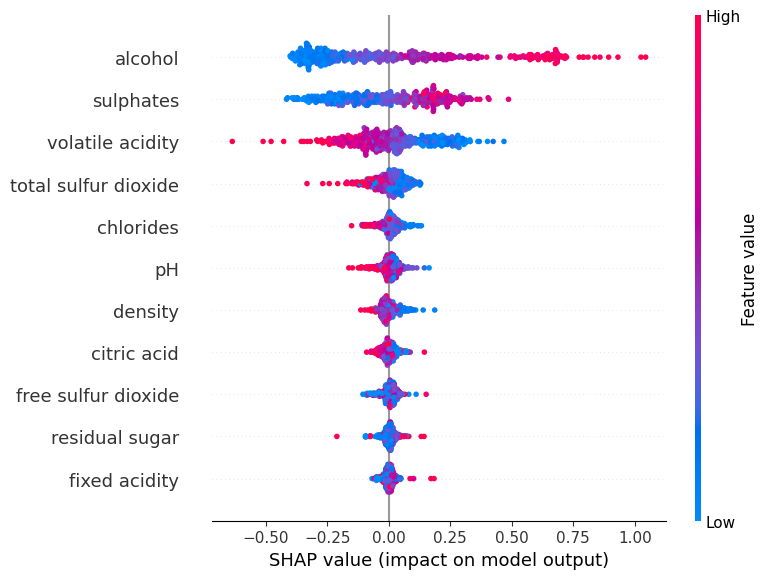

In [59]:
shap.summary_plot(shap_values_rf, X_test)

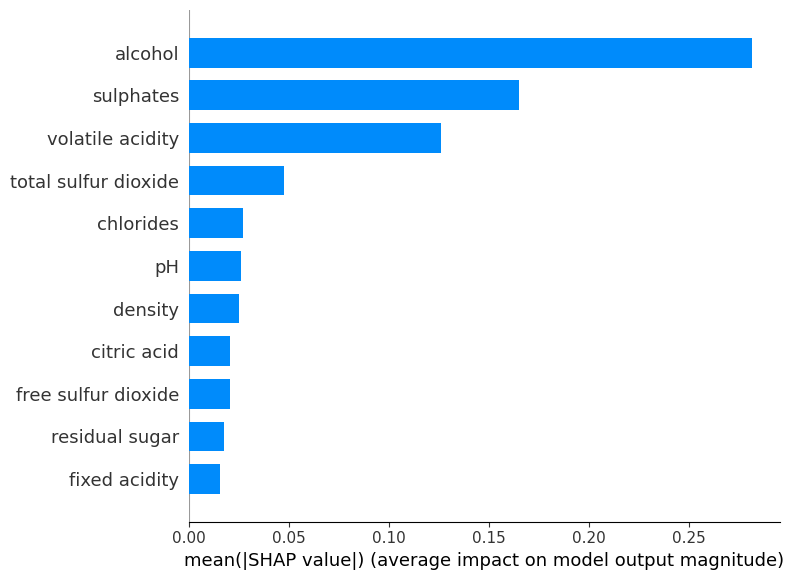

In [60]:
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")

### Interpretarea graficelor SHAP pentru Random Forest Regressor

Graficele SHAP pentru Random Forest Regressor arată că cele mai importante caracteristici în predicția scorului 'quality' sunt 'alcohol', 'sulphates' și 'volatile acidity'.

În summary plot se observă că valorile mari ale caracteristicilor 'alcohol' și 'sulphates' au, în general, valori SHAP pozitive, deci tind să crească predicția scorului de calitate. Valorile mai mici ale acestora tind să împingă predicția în jos.

În cazul caracteristicii 'volatile acidity', se observă efectul invers: valorile mari tind să aibă valori SHAP negative, deci scad predicția scorului 'quality'. Acest lucru indică faptul că o aciditate volatilă ridicată este asociată cu o calitate mai redusă a vinului.

In [61]:
explainer_cat = shap.TreeExplainer(best_cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)

print("Dimensiune SHAP values:", shap_values_cat.shape)
print("Dimensiune X_test:", X_test.shape)

Dimensiune SHAP values: (425, 11)
Dimensiune X_test: (425, 11)


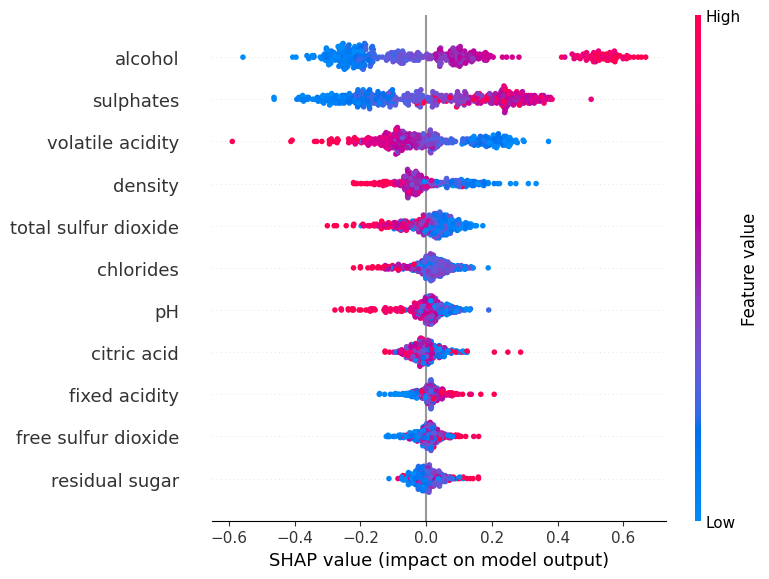

In [62]:
shap.summary_plot(shap_values_cat, X_test)

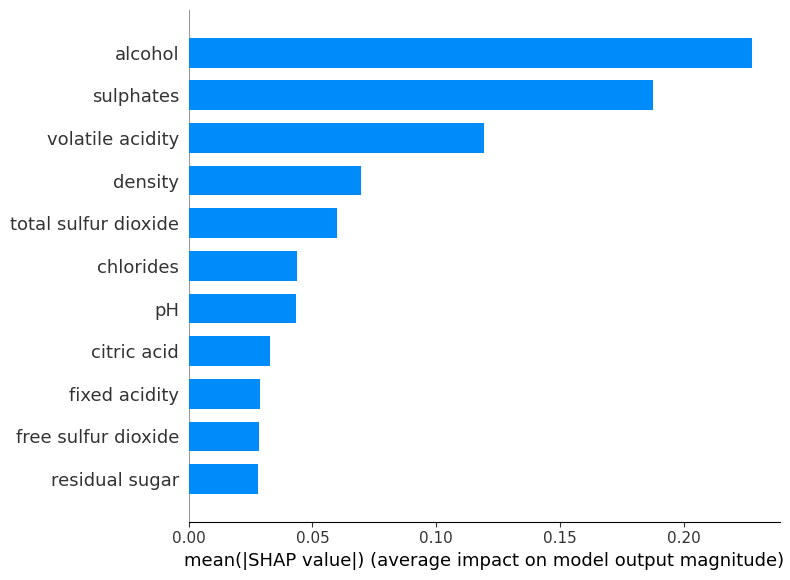

In [63]:
shap.summary_plot(shap_values_cat, X_test, plot_type="bar")

### Interpretarea graficelor SHAP pentru CatBoost Regressor

Graficele SHAP pentru CatBoost Regressor oferă rezultate asemănătoare cu cele obținute la Random Forest Regressor. Cele mai importante caracteristici rămân 'alcohol', 'sulphates' și 'volatile acidity', ceea ce confirmă faptul că acestea au cea mai mare influență asupra predicției scorului 'quality'.

Importanța unor caracteristici secundare, precum 'density', 'total sulfur dioxide' sau 'chlorides', se modifică față de Random Forest, însă primele trei caracteristici rămân aceleași.

In [64]:
explainer_xgb = shap.TreeExplainer(best_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print("Dimensiune SHAP values:", shap_values_xgb.shape)
print("Dimensiune X_test:", X_test.shape)

Dimensiune SHAP values: (425, 11)
Dimensiune X_test: (425, 11)


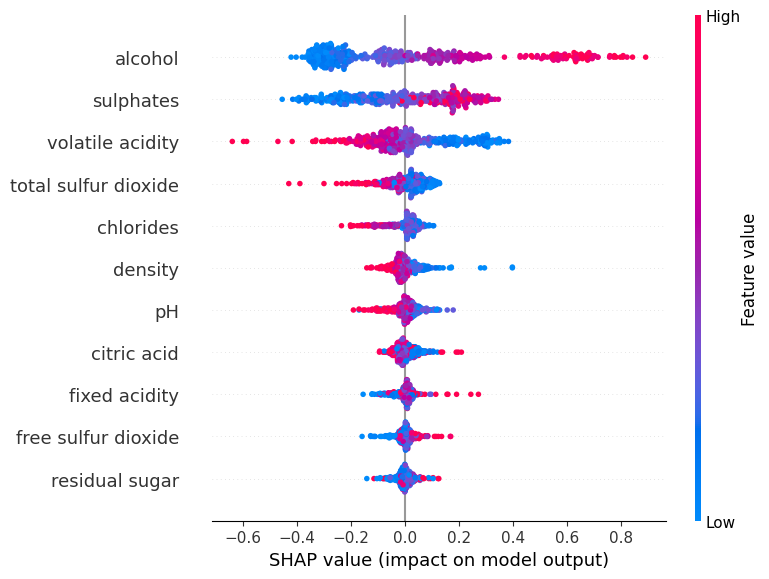

In [65]:
shap.summary_plot(shap_values_xgb, X_test)

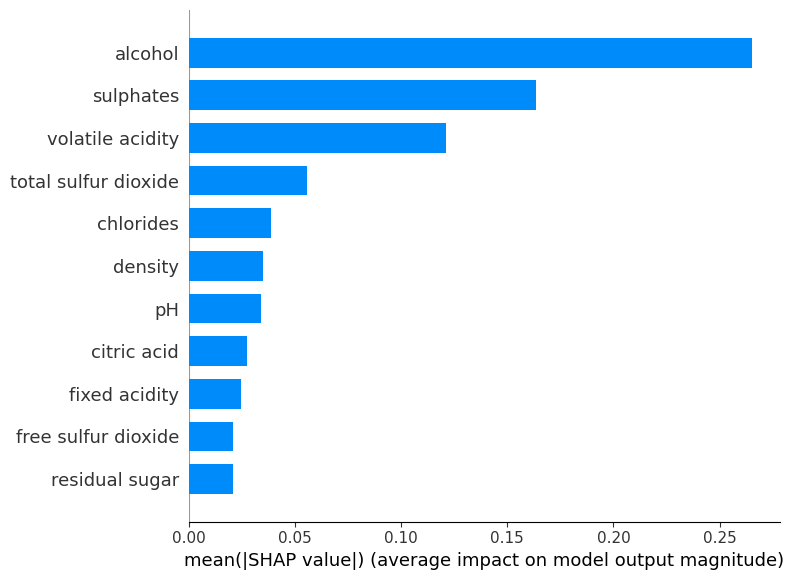

In [66]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

### Interpretarea graficelor SHAP pentru XGBoost Regressor

Graficele SHAP pentru XGBoost Regressor confirmă rezultatele obținute la Random Forest și CatBoost.

Prin urmare, cele trei modele analizate cu SHAP indică aceeași concluzie principală: scorul de calitate al vinului este influențat în special de 'alcohol', 'sulphates' și 'volatile acidity'.

In [67]:
example_index = 0

example_data = X_test.iloc[[example_index]]
example_real_value = y_test.iloc[example_index]
example_prediction = best_rf_model.predict(example_data)[0]

print("Datele exemplului analizat:")
display(example_data)

print("Valoare reala quality:", example_real_value)
print("Predictie model:", example_prediction)

Datele exemplului analizat:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
619,11.3,0.37,0.41,2.3,0.088,6.0,16.0,0.9988,3.09,0.8,9.3


Valoare reala quality: 5.0
Predictie model: 5.76402002168677


### Exemplu local analizat

Pentru explicația locală a fost ales primul exemplu din setul de testare.

Valoarea reală a variabilei 'quality' pentru acest exemplu este 5.0, iar modelul Random Forest Regressor optimizat a prezis valoarea aproximativă 5.764.

Predicția este mai mare decât valoarea reală, ceea ce înseamnă că modelul a supraestimat calitatea vinului pentru acest exemplu.

În continuare, se folosesc graficele SHAP pentru a observa ce caracteristici au contribuit cel mai mult la această predicție.

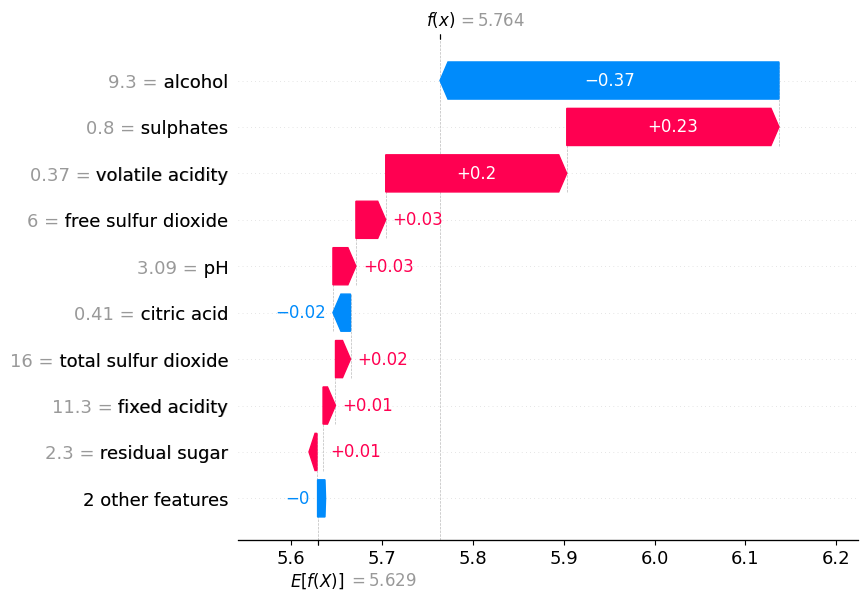

In [69]:
example_shap_values = shap_values_rf[example_index]
example_base_value = explainer_rf.expected_value

if isinstance(example_base_value, np.ndarray):
    example_base_value = example_base_value[0]

shap_explanation_rf = shap.Explanation(
    values=example_shap_values,
    base_values=example_base_value,
    data=X_test.iloc[example_index],
    feature_names=X_test.columns
)

shap.plots.waterfall(shap_explanation_rf)

### Interpretarea waterfall plot pentru Random Forest Regressor

Graficul waterfall explică predicția locală pentru primul exemplu din setul de testare. Valoarea de bază a modelului este aproximativ 5.629, iar predicția finală pentru acest exemplu este aproximativ 5.764.

Cea mai mare influență negativă o are caracteristica 'alcohol', cu valoarea 9.3, care scade predicția cu aproximativ 0.37.

Cele mai importante influențe pozitive sunt 'sulphates' și 'volatile acidity'. Aceste caracteristici împing predicția în sus față de valoarea de bază.

Alte caracteristici, precum 'free sulfur dioxide', 'pH', 'total sulfur dioxide', 'fixed acidity' și 'residual sugar', au contribuții mai mici asupra predicției finale.

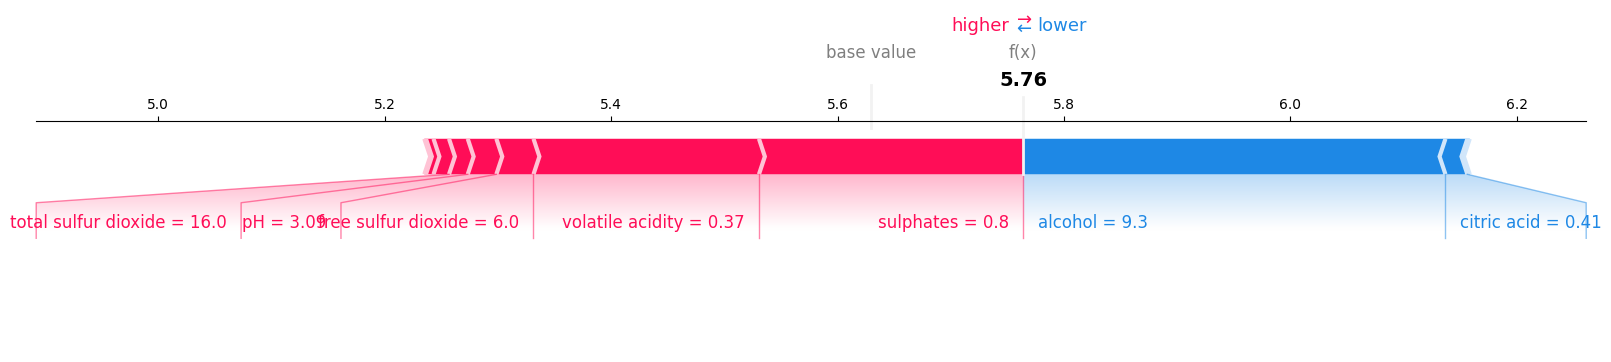

In [70]:
shap.initjs()

shap.force_plot(
    explainer_rf.expected_value,
    shap_values_rf[example_index],
    X_test.iloc[example_index],
    matplotlib=True
)

### Interpretare force plot pentru Random Forest Regressor

Force plot-ul prezintă contribuția caracteristicilor pentru aceeași predicție locală analizată anterior.

Caracteristicile marcate cu roșu împing predicția în sus, iar cele marcate cu albastru împing predicția în jos.

Prin urmare, predicția finală este rezultatul echilibrului dintre influențele pozitive și negative ale caracteristicilor, modelul ajungând la o valoare estimată a scorului 'quality' de aproximativ 5.76.

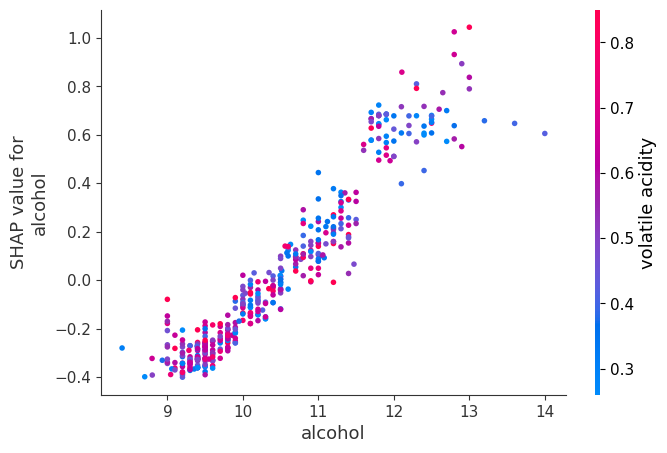

In [71]:
shap.dependence_plot("alcohol", shap_values_rf, X_test)

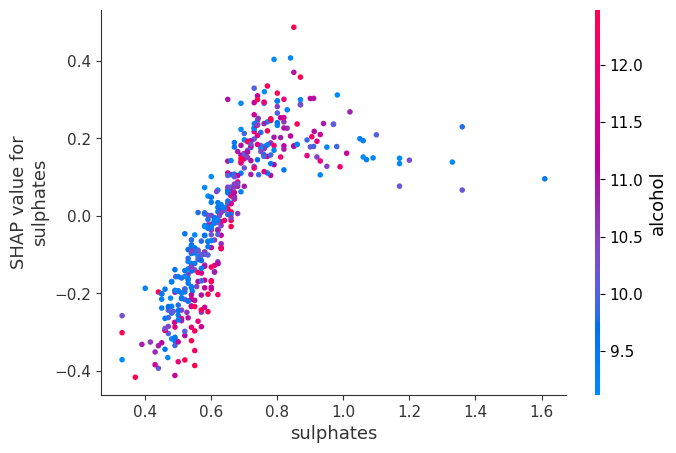

In [72]:
shap.dependence_plot("sulphates", shap_values_rf, X_test)

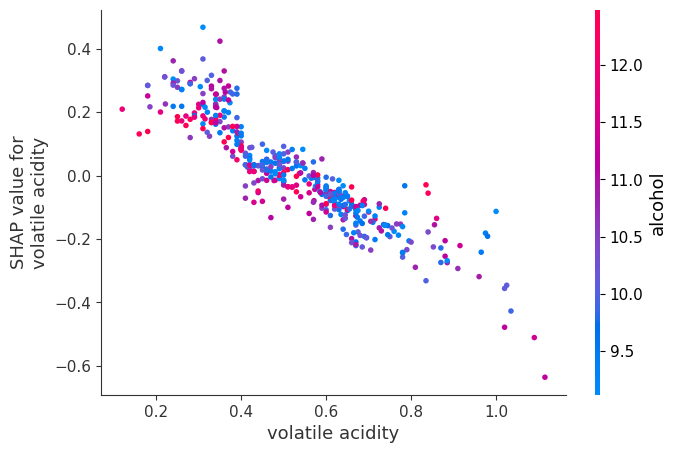

In [73]:
shap.dependence_plot("volatile acidity", shap_values_rf, X_test)

### Interpretarea SHAP scatter plot pentru Random Forest Regressor

Scatter plot-urile arată influența celor mai importante caracteristici asupra predicției modelului.

Pentru 'alcohol' și 'sulphates', se observă o relație pozitivă: valorile mai mari tind să crească valoarea SHAP și, implicit, predicția scorului 'quality'.

Pentru 'volatile acidity', relația este negativă: valorile mai mari tind să scadă valoarea SHAP și predicția scorului 'quality'.

## Concluzie privind analiza SHAP

Analiza SHAP a arătat că cele mai importante caracteristici pentru predicția scorului 'quality' sunt 'alcohol', 'sulphates' și 'volatile acidity'.

Rezultatele au fost similare pentru modelele analizate, ceea ce confirmă faptul că aceste caracteristici au cea mai mare influență asupra predicțiilor. Valorile mai mari pentru 'alcohol' și 'sulphates' tind să crească scorul estimat al calității, în timp ce valorile mai mari pentru 'volatile acidity' tind să îl scadă.

Explicațiile locale, prin waterfall plot și force plot, au arătat cum contribuie fiecare caracteristică la o predicție concretă. Astfel, SHAP oferă atât o interpretare globală a modelului, cât și o explicație locală.

În concluzie, analiza SHAP confirmă că modelul Random Forest Regressor optimizat ia deciziile pe baza unor caracteristici relevante și ușor de interpretat în contextul calității vinului.

In [74]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

joblib.dump(best_rf_model, "../models/random_forest_regressor_model.pkl")
joblib.dump(best_cat_model, "../models/catboost_regressor_model.pkl")
joblib.dump(best_xgb_model, "../models/xgboost_regressor_model.pkl")
joblib.dump(best_ebr_model, "../models/explainable_boosting_regressor_model.pkl")
joblib.dump(best_lr_model, "../models/linear_regression_model.pkl")

h_results_sorted.to_csv("../results/tuned_regression_models_results.csv", index=False)